<a href="https://colab.research.google.com/github/bibeko7/diabetes_prediction/blob/main/diabetes_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


#load diabetes data_set

In [ ]:
data=pd.read_csv('//content//diabetes.csv')

In [ ]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
data.shape

(768, 9)

#check null NAN value in data_set

In [ ]:
data.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


#check duplicate data

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

#most of the data set is null so apply

In [ ]:
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

data[cols] = data[cols].replace(0, np.nan)
data[cols] = data[cols].fillna(data[cols].median())

print(data.head(20).to_string())


    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  DiabetesPedigreeFunction  Age  Outcome
0             6    148.0           72.0           35.0    125.0  33.6                     0.627   50        1
1             1     85.0           66.0           29.0    125.0  26.6                     0.351   31        0
2             8    183.0           64.0           29.0    125.0  23.3                     0.672   32        1
3             1     89.0           66.0           23.0     94.0  28.1                     0.167   21        0
4             0    137.0           40.0           35.0    168.0  43.1                     2.288   33        1
5             5    116.0           74.0           29.0    125.0  25.6                     0.201   30        0
6             3     78.0           50.0           32.0     88.0  31.0                     0.248   26        1
7            10    115.0           72.0           29.0    125.0  35.3                     0.134   29        0
8         

#again check null value

In [ ]:
(data[cols] == 0).sum()


,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0


#check data is they bias to any class or not

In [ ]:
data['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


#visualize outcome or target data

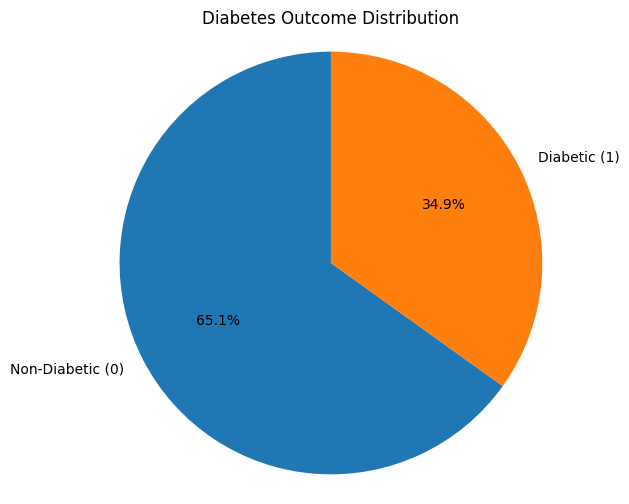

In [ ]:
import matplotlib.pyplot as plt

counts = data['Outcome'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    counts.values,
    labels=['Non-Diabetic (0)', 'Diabetic (1)'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Diabetes Outcome Distribution")
plt.axis('equal')   # Makes pie chart circular
plt.show()


#visualization data_set

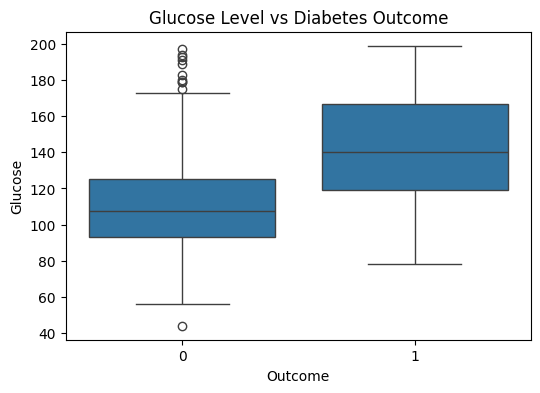

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Outcome", y="Glucose", data=data)
plt.title("Glucose Level vs Diabetes Outcome")
plt.show()


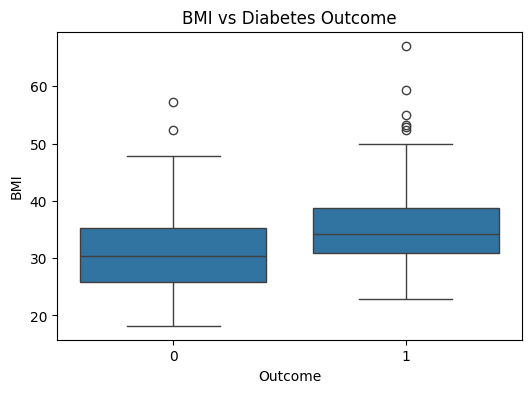

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Outcome", y="BMI", data=data)
plt.title("BMI vs Diabetes Outcome")
plt.show()


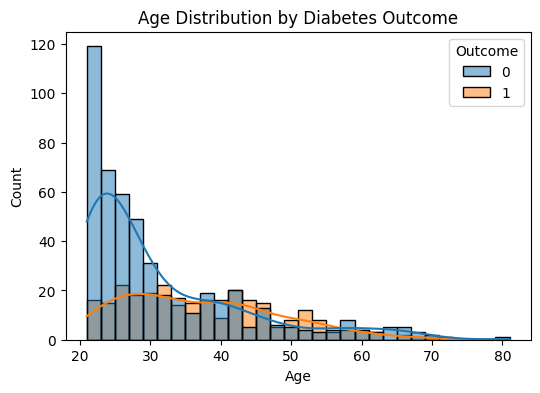

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(data=data, x="Age", hue="Outcome", bins=30, kde=True)
plt.title("Age Distribution by Diabetes Outcome")
plt.show()


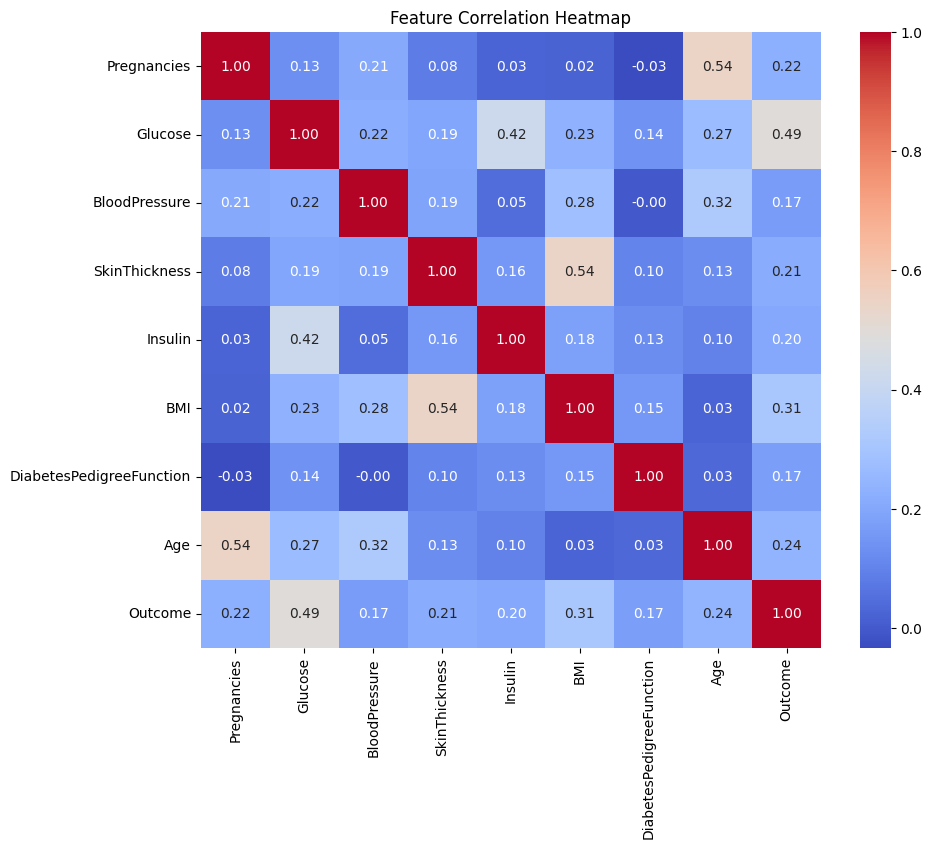

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


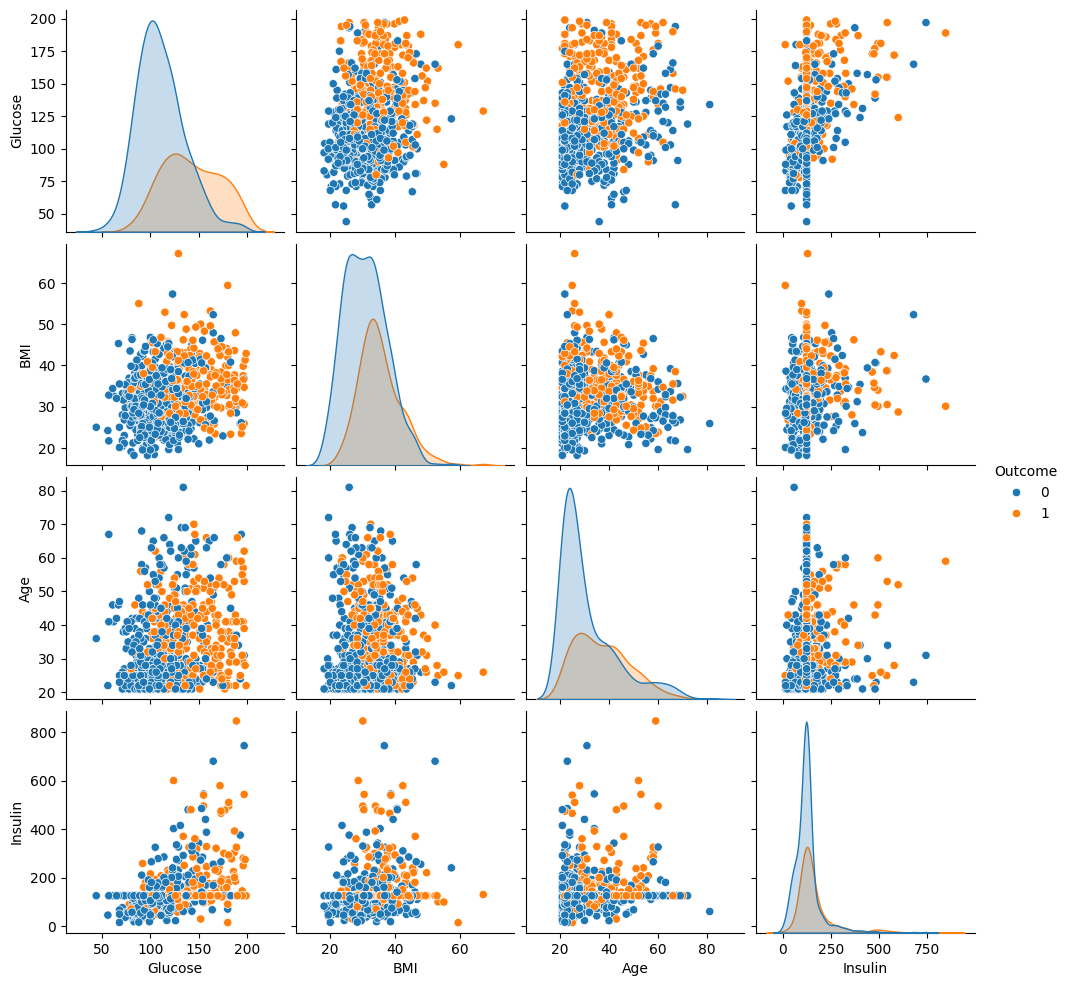

In [ ]:
sns.pairplot(
    data,
    vars=["Glucose", "BMI", "Age", "Insulin"],
    hue="Outcome"
)
plt.show()


#features and target sepearation

In [ ]:
x=data.drop('Outcome',axis=1) #features
y=data['Outcome']             #target

#perform train test split data set

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

#features scaling

In [ ]:
sclaer=StandardScaler()
x_train_scale=sclaer.fit_transform(x_train)
x_test_scale=sclaer.transform(x_test)

In [ ]:
log=LogisticRegression(max_iter=3000,
                       n_jobs=-1,
                      class_weight='balanced',
                       random_state=42,
                       penalty='l2',
                       C=1.0,
                      solver='lbfgs',

                        )


In [ ]:
log.fit(x_train_scale,y_train)

LogisticRegression(class_weight='balanced', max_iter=3000, n_jobs=-1,
                   random_state=42)

In [ ]:
y_pred=log.predict(x_test_scale)

In [ ]:
log.coef_     # Feature coefficients

array([[ 0.2383326 ,  1.13117766, -0.16740467,  0.07606671, -0.12790741,
         0.70807921,  0.23898379,  0.4424476 ]])

In [ ]:

log.intercept_            # Bias

array([-0.25819727])

In [ ]:
log.predict(x_test_scale)

array([0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0])

#this indicates probability of no diabetes and diabetes

In [ ]:
log.predict_proba(x_test_scale)


array([[0.57392365, 0.42607635],
       [0.74703882, 0.25296118],
       [0.8322562 , 0.1677438 ],
       [0.74390858, 0.25609142],
       [0.37462195, 0.62537805],
       [0.38889705, 0.61110295],
       [0.97766363, 0.02233637],
       [0.44436976, 0.55563024],
       [0.27794688, 0.72205312],
       [0.12790225, 0.87209775],
       [0.6529472 , 0.3470528 ],
       [0.05365926, 0.94634074],
       [0.47099891, 0.52900109],
       [0.56516228, 0.43483772],
       [0.87154504, 0.12845496],
       [0.42706792, 0.57293208],
       [0.81981063, 0.18018937],
       [0.88065575, 0.11934425],
       [0.16487635, 0.83512365],
       [0.28405448, 0.71594552],
       [0.69913851, 0.30086149],
       [0.8777176 , 0.1222824 ],
       [0.31839703, 0.68160297],
       [0.85190949, 0.14809051],
       [0.29034973, 0.70965027],
       [0.05921914, 0.94078086],
       [0.82727419, 0.17272581],
       [0.95451168, 0.04548832],
       [0.62348624, 0.37651376],
       [0.82487064, 0.17512936],
       [0.

In [ ]:
log.score(x_test_scale,y_test)


0.7012987012987013

#accuracy generated by using holdout method(train_test_split)

In [ ]:
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.70


In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print('confusion metrix:\n',cm)

confusion metrix:
 [[69 30]
 [16 39]]


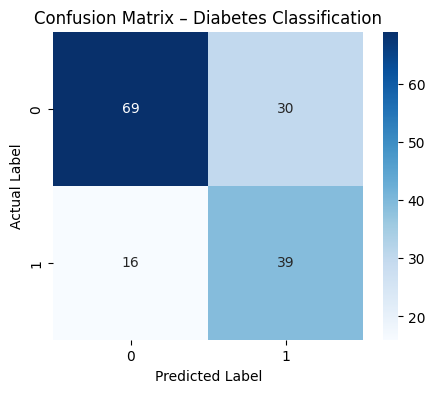

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = [[69, 30],
      [16, 39]]

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix – Diabetes Classification")
plt.show()


#Cross-validation averages performance across multiple folds

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Define pipeline (scaling + model)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=3000))
])

# K-Fold setup
kfold = KFold(
    n_splits=5,        # 5-Fold Cross Validation
    shuffle=True,
    random_state=42
)

# Perform cross-validation
cv_scores = cross_val_score(
    pipeline,
    x,
    y,
    cv=kfold,
    scoring='accuracy'
)

print("Accuracy for each fold:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())


Accuracy for each fold: [0.75324675 0.78571429 0.74675325 0.81699346 0.75163399]
Mean Accuracy: 0.7708683473389355
Standard Deviation: 0.02686986249717815


#confusion matrix with cross validation

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n",
      classification_report(y_test, y_pred))


Confusion Matrix:
 [[69 30]
 [16 39]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.70      0.75        99
           1       0.57      0.71      0.63        55

    accuracy                           0.70       154
   macro avg       0.69      0.70      0.69       154
weighted avg       0.72      0.70      0.71       154



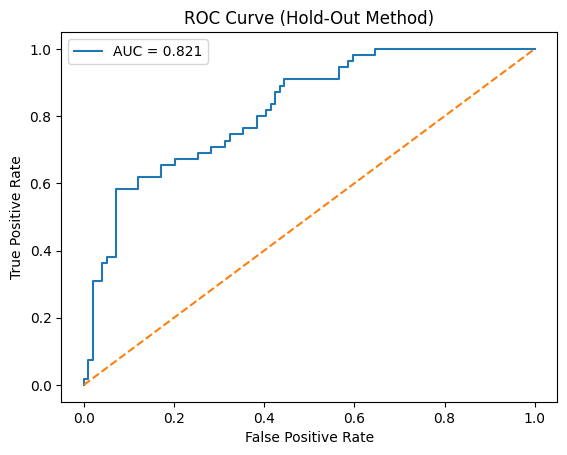

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = log.predict_proba(x_test_scale)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Hold-Out Method)")
plt.legend()
plt.show()
